In [ ]:
# FAZA 5 — Modelovanje: duboki modeli (LSTM, GRU, Transformer)
#
# Koristim iste skupove atributa i istu vremensku podelu (train/valid/test)
# kao u Fazi 4, ali podatke organizujem u sekvence po entitetu, poredjane
# hronološki po vremenskom prozoru. LSTM, GRU i Transformer ne dobijaju
# ručno napravljene istorijske atribute jedan po jedan (kao klasični modeli),
# već čitav niz prethodnih prozora, pa sami uče vremenski obrazac.
#
# Sva tri modela se treniraju i evaluiraju na potpuno isti način (ista
# funkcija za treniranje, ista funkcija za evaluaciju, ista mera za
# disbalans klasa), da bi poređenje bilo pravedno.

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import RobustScaler
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
)

warnings.filterwarnings("ignore")

PROC = Path(__file__).resolve().parent.parent / "data" / "processed"
RESULTS = Path(__file__).resolve().parent.parent / "results"
MODELS = Path(__file__).resolve().parent.parent / "models"
RESULTS.mkdir(exist_ok=True)
MODELS.mkdir(exist_ok=True)

SEED = 7
np.random.seed(SEED)
torch.manual_seed(SEED)


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Uređaj za treniranje:", DEVICE)

Uređaj za treniranje: cpu


In [ ]:
# --- 1. Učitavanje podataka iz Faze 3 (isti izvor kao kod klasičnih modela) ---

vremenski_prozori = pd.read_parquet(PROC / "features.parquet")

with open(PROC / "selected_features.json", encoding="utf-8") as f:
    atributi_final = json.load(f)
with open(PROC / "features_after_filter.json", encoding="utf-8") as f:
    atributi_filter = json.load(f)
with open(PROC / "features_full.json", encoding="utf-8") as f:
    atributi_full = json.load(f)
with open(PROC / "imputation_values.json", encoding="utf-8") as f:
    imputation_values = json.load(f)
# has_history je napravljen u Fazi 3 samo na treningu i nije sačuvan u
# features.parquet, pa se rekreira ovde na isti način kao u Fazi 4.
vremenski_prozori["has_history"] = (vremenski_prozori["window_seq_num"] >= 1).astype(
    int
)

# Imputacija istim vrednostima izračunatim na treningu u Fazi 3.
for kolona, vrednost in imputation_values.items():
    if kolona in vremenski_prozori.columns:
        vremenski_prozori[kolona] = vremenski_prozori[kolona].fillna(vrednost)


SKUPOVI_ATRIBUTA = {
    "Final (11)": atributi_final,
    "Filter (40)": atributi_filter,
    "Full (53)": atributi_full,
}

print("Ukupno redova:", len(vremenski_prozori))
for naziv, kolone in SKUPOVI_ATRIBUTA.items():
    print(f"{naziv}: {len(kolone)} atributa")

Ukupno redova: 224180
Final (11): 11 atributa
Filter (40): 40 atributa
Full (53): 53 atributa


In [ ]:
# --- 2. Pravljenje sekvenci po entitetu ---
# LSTM, GRU i Transformer očekuju ulaz oblika (batch, koraci, atributi).
# Za svaki red (trenutni prozor) pravim sekvencu od SEQ_LEN uzastopnih
# prozora istog entiteta, računajući unazad i uključujući trenutni prozor.
# Ako entitet nema dovoljno istorije, sekvenca se popunjava nulama sa leve
# strane (padding), pa svaka sekvenca ima istu dužinu.

SEQ_LEN = 10  # broj uzastopnih vremenskih prozora u jednoj sekvenci


def napravi_sekvence(df, kolone, seq_len):
    """Vraća (df sortiran po entity+window_id, niz oblika (n_redova, seq_len, n_atributa))."""
    df = df.sort_values(["entity", "window_id"]).reset_index(drop=True)
    vrednosti = df[kolone].to_numpy(dtype=np.float32)
    sekvence = np.zeros((len(df), seq_len, len(kolone)), dtype=np.float32)

    for _, grupa in df.groupby("entity", sort=False):
        idx = grupa.index.to_numpy()
        podaci_entiteta = vrednosti[idx]
        for i in range(len(idx)):
            pocetak = max(0, i - seq_len + 1)
            deo_istorije = podaci_entiteta[pocetak : i + 1]
            sekvence[idx[i], seq_len - len(deo_istorije) :, :] = deo_istorije

    return df, sekvence

In [ ]:
# --- 3. PyTorch Dataset ---
# DataLoader-i se sada prave posebno za svaki skup atributa
# (ćelija 4), jer svaki skup ima svoje podatke i svoj broj kolona.
#
# LSTM, GRU i Transformer moraju biti u obliku (batch, koraci, atributi).
class ProzorDataset(Dataset):
    """Jedan primer = jedna sekvenca prozora (X) i oznaka poslednjeg prozora (y)."""

    def __init__(self, X, y):
        self.X = torch.from_numpy(X)
        self.y = torch.from_numpy(y.to_numpy(dtype=np.float32))

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]


BATCH_SIZE = 256
# shuffle=True na treningu meša redosled sekvenci u svakoj epohi radi bolje
# generalizacije gradijentnog spusta, dok je na validaciji shuffle=False
# da bi predikcije ostale u strogo fiksiranom redosledu radi tačne evaluacije.

In [ ]:
# --- 4. Priprema podataka za sva tri skupa ---
# Objedinjuje skaliranje i pravljenje sekvenci za sva tri skupa atributa.
# Svaki skup dobija sopstveni RobustScaler, jer ima drugačiji broj i
# sastav kolona.
podaci_po_skupu = {}

for naziv_skupa, kolone in SKUPOVI_ATRIBUTA.items():
    df = vremenski_prozori.copy()

    # RobustScaler se uči isključivo na treningu, da ne bi došlo do curenja
    # informacija iz validacije/testa, isto pravilo kao u prethodnim fazama.
    skaler = RobustScaler()
    trening_maska = df["split"] == "train"
    skaler.fit(df.loc[trening_maska, kolone])
    df[kolone] = skaler.transform(df[kolone])

    df, X_sve = napravi_sekvence(df, kolone, SEQ_LEN)

    train_maska = (df["split"] == "train").to_numpy()
    val_maska = (df["split"] == "valid").to_numpy()

    y_train_s = df.loc[train_maska, "is_attack"].reset_index(drop=True)
    y_val_s = df.loc[val_maska, "is_attack"].reset_index(drop=True)

    train_loader = DataLoader(
        ProzorDataset(X_sve[train_maska], y_train_s),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    val_loader = DataLoader(
        ProzorDataset(X_sve[val_maska], y_val_s), batch_size=BATCH_SIZE, shuffle=False
    )

    podaci_po_skupu[naziv_skupa] = {
        "kolone": kolone,
        "train_loader": train_loader,
        "val_loader": val_loader,
        "y_train": y_train_s,
    }
    print(f"{naziv_skupa}: pripremljeno, {int(y_train_s.sum())} pozitivnih na treningu")

Final (11): pripremljeno, 101 pozitivnih na treningu
Filter (40): pripremljeno, 101 pozitivnih na treningu
Full (53): pripremljeno, 101 pozitivnih na treningu


In [ ]:
# --- 5. Definicija tri modela ---
# "Dublji" model = više slojeva naslaganih jedan na drugi. Kod LSTM-a i GRU-a je to
# parametar num_layers (ugrađen u PyTorch, ne treba ga ručno praviti u petlji):
# izlaz prvog sloja postaje ulaz drugom i tako dalje. Kod Transformera je to
# broj TransformerEncoderLayer blokova (n_slojeva). Dropout između slojeva
# se koristi samo kad ima više od jednog sloja, jer sprečava da mreža sa više
# parametara prelako "zapamti" trening skup (overfitting).
class LSTMKlasifikator(nn.Module):
    def __init__(self, n_atributa, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=n_atributa,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.izlaz = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, (h_n, _) = self.lstm(x)
        poslednje_stanje = h_n[
            -1
        ]  # skriveno stanje poslednjeg sloja posle poslednjeg koraka
        return self.izlaz(poslednje_stanje).squeeze(1)


class GRUKlasifikator(nn.Module):
    def __init__(self, n_atributa, hidden_size=32, num_layers=2, dropout=0.2):
        super().__init__()
        self.gru = nn.GRU(
            input_size=n_atributa,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
        )
        self.izlaz = nn.Linear(hidden_size, 1)

    def forward(self, x):
        _, h_n = self.gru(x)
        poslednje_stanje = h_n[-1]  # skriveno stanje POSLEDNJEG sloja
        return self.izlaz(poslednje_stanje).squeeze(1)


class TransformerKlasifikator(nn.Module):
    def __init__(
        self, n_atributa, seq_len, d_model=32, n_head=2, n_slojeva=2, dropout=0.2
    ):
        super().__init__()
        self.projekcija = nn.Linear(n_atributa, d_model)
        self.pozicije = nn.Embedding(seq_len, d_model)  # uči redosled koraka u sekvenci
        sloj = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_head,
            dim_feedforward=64,
            dropout=dropout,
            batch_first=True,
        )
        # num_layers ovde slaže n_slojeva kopija istog bloka jednu za drugom
        self.enkoder = nn.TransformerEncoder(sloj, num_layers=n_slojeva)
        self.izlaz = nn.Linear(d_model, 1)

    def forward(self, x):
        batch, koraci, _ = x.shape
        pozicije_idx = (
            torch.arange(koraci, device=x.device).unsqueeze(0).expand(batch, -1)
        )
        x = self.projekcija(x) + self.pozicije(pozicije_idx)
        x = self.enkoder(x)
        poslednji_korak = x[
            :, -1, :
        ]  # predstavlja ceo prozor istorije do trenutnog koraka
        return self.izlaz(poslednji_korak).squeeze(1)

In [ ]:
# --- 6. Zajednička funkcija za treniranje i evaluaciju (ista za sva tri modela) ---
def evaluiraj_model(model, loader):
    """Vraća predviđene verovatnoće, Average Precision i AUC-ROC za dati loader."""
    model.eval()
    sve_verovatnoce, sve_oznake = [], []
    with torch.no_grad():
        for X_batch, y_batch in loader:
            logiti = model(X_batch.to(DEVICE))
            sve_verovatnoce.append(torch.sigmoid(logiti).cpu().numpy())
            sve_oznake.append(y_batch.numpy())
    p = np.concatenate(sve_verovatnoce)
    y = np.concatenate(sve_oznake)
    return p, average_precision_score(y, p), roc_auc_score(y, p)


def treniraj_model(
    model, train_loader, val_loader, y_train, epohe=30, lr=1e-3, strpljenje=5
):
    """Trenira model epohu po epohu i vraća AP na validaciji posle svake epohe."""
    model.to(DEVICE)
    broj_pozitivnih = y_train.sum()
    broj_negativnih = len(y_train) - broj_pozitivnih
    pos_weight = torch.tensor(
        [broj_negativnih / broj_pozitivnih], dtype=torch.float32, device=DEVICE
    )
    kriterijum = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    optimizator = torch.optim.Adam(model.parameters(), lr=lr)

    najbolji_ap = -1.0
    najbolje_tezine = None
    epoha_bez_poboljsanja = 0
    istorija_ap = []

    for epoha in range(1, epohe + 1):
        model.train()
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            optimizator.zero_grad()
            gubitak = kriterijum(model(X_batch), y_batch)
            gubitak.backward()
            optimizator.step()

        _, ap_val, _ = evaluiraj_model(model, val_loader)
        istorija_ap.append(ap_val)
        print(f"  Epoha {epoha}/{epohe} - AP na validaciji: {ap_val:.4f}")

        if ap_val > najbolji_ap:
            najbolji_ap = ap_val
            najbolje_tezine = {k: v.clone() for k, v in model.state_dict().items()}
            epoha_bez_poboljsanja = 0
        else:
            epoha_bez_poboljsanja += 1
            if epoha_bez_poboljsanja >= strpljenje:
                print(
                    f"  Nema poboljšanja {strpljenje} epohe zaredom, prekidam ranije."
                )
                break

    model.load_state_dict(najbolje_tezine)
    return istorija_ap


# pos_weight u funkciji greške igra istu ulogu kao class_weight="balanced"
# kod klasičnih modela: bez njega bi mreža, zbog ogromnog disbalansa,
# naučila da uvek predviđa is_attack = 0. Za razliku od Faze 4, gde je
# balansiranje štetilo Random Forest-u i Decision Tree-u, neuronske mreže uče
# kroz gradijentni spust, kod kog je "uvek predviđaj većinsku klasu"
# stabilan lokalni minimum, pa je pos_weight ovde neophodan.
#
# Rano zaustavljanje (early stopping): posle svake epohe se pamte težine
# modela ako je AP na validaciji bolji od dotadašnjeg najboljeg. Ako broj
# uzastopnih epoha bez poboljšanja dostigne vrednost parametra "strpljenje",
# treniranje se prekida i vraćaju se najbolje zapamćene težine (ne poslednje),
# da model ne bi overfit-ovao trening skup u kasnijim epohama.

In [ ]:
# --- 7. Treniranje sva tri modela pod istim uslovima ---
# Treniranje se ponavlja za sva tri skupa atributa (9 treninga ukupno: 3 modela x 3 skupa),
# koristeći podatke pripremljene u ćeliji 4.

EPOHE = 30  # gornja granica; rano zaustavljanje obično prekine trening ranije
BROJ_SLOJEVA = (
    2  # isti broj naslaganih slojeva za sva tri modela, radi poštenog poređenja
)
STRPLJENJE = 5  # rano zaustavljanje: broj epoha bez poboljšanja pre prekida

istorije = {}  # (skup, model) -> niz AP po epohama
modeli_trenirani = {}  # (skup, model) -> istrenirani model objekat
rezultati = []

for naziv_skupa, kolone in SKUPOVI_ATRIBUTA.items():
    print(f"\n--- Skup atributa: {naziv_skupa} ---")

    train_loader = podaci_po_skupu[naziv_skupa]["train_loader"]
    val_loader = podaci_po_skupu[naziv_skupa]["val_loader"]
    y_train_s = podaci_po_skupu[naziv_skupa]["y_train"]

    modeli = {
        "LSTM": LSTMKlasifikator(n_atributa=len(kolone), num_layers=BROJ_SLOJEVA),
        "GRU": GRUKlasifikator(n_atributa=len(kolone), num_layers=BROJ_SLOJEVA),
        "Transformer": TransformerKlasifikator(
            n_atributa=len(kolone), seq_len=SEQ_LEN, n_slojeva=BROJ_SLOJEVA
        ),
    }

    for naziv_modela, model in modeli.items():
        print(f"\n--- Treniranje modela: {naziv_skupa} / {naziv_modela} ---")
        istorije[(naziv_skupa, naziv_modela)] = treniraj_model(
            model,
            train_loader,
            val_loader,
            y_train_s,
            epohe=EPOHE,
            strpljenje=STRPLJENJE,
        )
        _, ap_val, auc_val = evaluiraj_model(model, val_loader)
        modeli_trenirani[(naziv_skupa, naziv_modela)] = model
        rezultati.append(
            {
                "Skup": naziv_skupa,
                "Model": naziv_modela,
                "AP val": round(ap_val, 4),
                "AUC-ROC val": round(auc_val, 4),
            }
        )

duboki_rezultati = (
    pd.DataFrame(rezultati)
    .sort_values("AP val", ascending=False)
    .reset_index(drop=True)
)
print("\nPoređenje dubokih modela na sva tri skupa atributa:")
print(duboki_rezultati.to_string(index=False))

duboki_rezultati.to_csv(RESULTS / "faza5_poredjenje_dubokih_modela.csv", index=False)
print("Sačuvano: results/faza5_poredjenje_dubokih_modela.csv")

# Najbolji rezultat ukupno postiže GRU na Filter skupu (AP=0,1311). LSTM
# ostaje najslabiji na sva tri skupa. Efekat skupa atributa nije
# jedinstven po arhitekturi: GRU najviše profitira od Filter skupa, dok
# Transformer najbolji rezultat postiže na Full skupu (AP=0,0784), tek
# neznatno iznad svog rezultata na Filter skupu (0,0774). Svi duboki
# modeli i dalje zaostaju za Random Forest-om (AP=0,2332) i XGBoost-om na
# Filter skupu (AP=0,1868).


--- Skup atributa: Final (11) ---

--- Treniranje modela: Final (11) / LSTM ---
  Epoha 1/30 - AP na validaciji: 0.0168
  Epoha 2/30 - AP na validaciji: 0.0329
  Epoha 3/30 - AP na validaciji: 0.0460
  Epoha 4/30 - AP na validaciji: 0.0491
  Epoha 5/30 - AP na validaciji: 0.0466
  Epoha 6/30 - AP na validaciji: 0.0587
  Epoha 7/30 - AP na validaciji: 0.0385
  Epoha 8/30 - AP na validaciji: 0.0442
  Epoha 9/30 - AP na validaciji: 0.0484
  Epoha 10/30 - AP na validaciji: 0.0497
  Epoha 11/30 - AP na validaciji: 0.0408
  Nema poboljšanja 5 epohe zaredom, prekidam ranije.

--- Treniranje modela: Final (11) / GRU ---
  Epoha 1/30 - AP na validaciji: 0.0348
  Epoha 2/30 - AP na validaciji: 0.0381
  Epoha 3/30 - AP na validaciji: 0.0413
  Epoha 4/30 - AP na validaciji: 0.0478
  Epoha 5/30 - AP na validaciji: 0.0506
  Epoha 6/30 - AP na validaciji: 0.0498
  Epoha 7/30 - AP na validaciji: 0.0532
  Epoha 8/30 - AP na validaciji: 0.0465
  Epoha 9/30 - AP na validaciji: 0.0529
  Epoha 10/30 - AP 

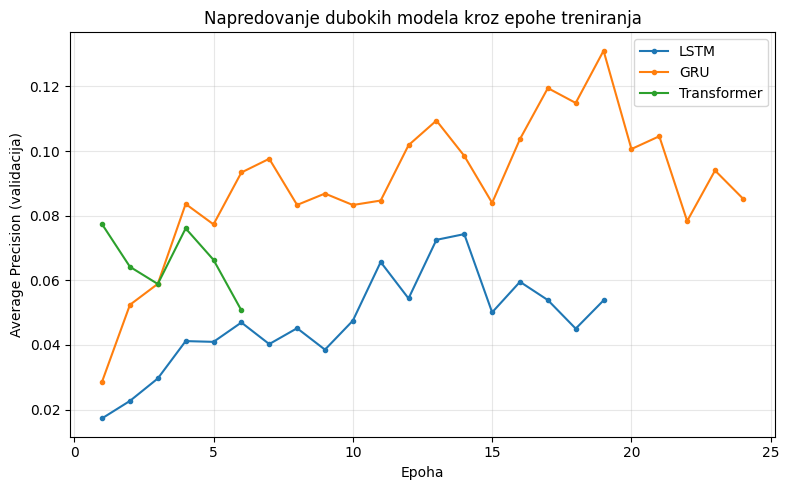

Grafik sačuvan: results/faza5_ap_kroz_epohe.png (skup: Filter (40))


In [ ]:
# --- 8. Grafik napredovanja AP na validaciji kroz epohe, za sva tri modela ---
# Prikazuju se krive samo za skup atributa koji je dao najbolji rezultat
# (ne sva tri skupa odjednom, to bi bilo 9 krivih na istom grafiku).
#
# Zahvaljujući ranom zaustavljanju modeli mogu da se treniraju različit broj
# epoha, zato se za svaki model crta njegova sopstvena dužina istorije.
najbolji_red = duboki_rezultati.iloc[0]
naziv_pobednickog_skupa = najbolji_red["Skup"]
naziv_najboljeg = najbolji_red["Model"]

plt.figure(figsize=(8, 5))
for naziv_modela in ["LSTM", "GRU", "Transformer"]:
    ap_niz = istorije[(naziv_pobednickog_skupa, naziv_modela)]
    plt.plot(
        range(1, len(ap_niz) + 1), ap_niz, marker="o", markersize=3, label=naziv_modela
    )
plt.xlabel("Epoha")
plt.ylabel("Average Precision (validacija)")
plt.title("Napredovanje dubokih modela kroz epohe treniranja")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "faza5_ap_kroz_epohe.png", dpi=120)
plt.show()
print(
    f"Grafik sačuvan: results/faza5_ap_kroz_epohe.png (skup: {naziv_pobednickog_skupa})"
)

# Kriva GRU-a na Filter skupu pokazuje rastuću oscilaciju sa vrhuncem na epohi 19 (AP=0,1311)
# nakon čega kreće da opada. Transformer dostiže vrhunac odmah na
# epohi 1 (AP≈0,077) zatim opada pa se oporavlja u epohi 4, uz rano zaustavljanje u epohi 5.
# LSTM raste sporo i nestabilno, sa vrhuncem tek na epohi 14
# (AP≈0,074), bez jasnog trenda poboljšanja nakon toga.

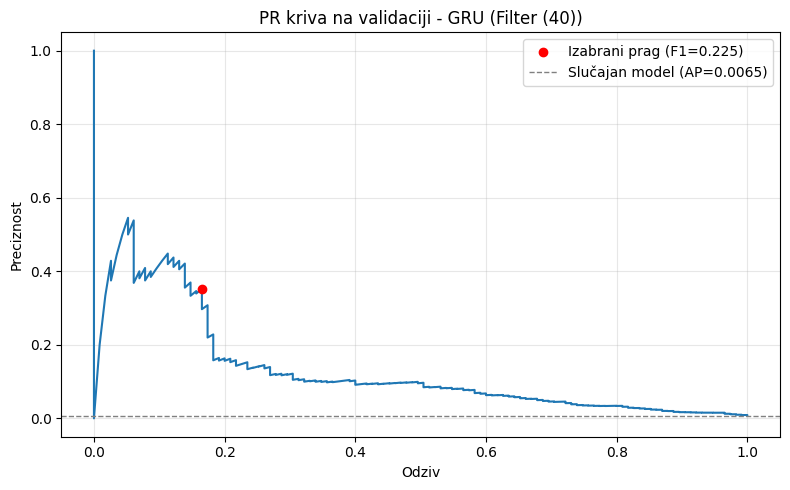

Najbolji duboki model: GRU (Filter (40))
Izabrani prag: 0.9943
Na validaciji -> preciznost: 0.3519, odziv: 0.1652, F1: 0.2249


In [ ]:
# --- 9. Biranje najboljeg modela i praga odlučivanja (isti postupak kao u Fazi 4) ---
model_najbolji = modeli_trenirani[(naziv_pobednickog_skupa, naziv_najboljeg)]
val_loader_pobednik = podaci_po_skupu[naziv_pobednickog_skupa]["val_loader"]
kolone_pobednik = podaci_po_skupu[naziv_pobednickog_skupa]["kolone"]

p_val, ap_val_najboljeg, auc_val_najboljeg = evaluiraj_model(
    model_najbolji, val_loader_pobednik
)
y_val_pobednik = val_loader_pobednik.dataset.y.numpy()

preciznost, odziv, pragovi = precision_recall_curve(y_val_pobednik, p_val)
f1 = 2 * preciznost * odziv / (preciznost + odziv + 1e-12)
idx_najbolji = np.argmax(f1[:-1])
prag = pragovi[idx_najbolji]

plt.figure(figsize=(8, 5))
plt.plot(odziv, preciznost)
plt.scatter(
    [odziv[idx_najbolji]],
    [preciznost[idx_najbolji]],
    color="red",
    zorder=5,
    label=f"Izabrani prag (F1={f1[idx_najbolji]:.3f})",
)
plt.axhline(
    y_val_pobednik.mean(),
    color="gray",
    linestyle="--",
    linewidth=1,
    label=f"Slučajan model (AP={y_val_pobednik.mean():.4f})",
)
plt.xlabel("Odziv")
plt.ylabel("Preciznost")
plt.title(f"PR kriva na validaciji - {naziv_najboljeg} ({naziv_pobednickog_skupa})")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS / "faza5_pr_kriva_validacije.png", dpi=120)
plt.show()

print(f"Najbolji duboki model: {naziv_najboljeg} ({naziv_pobednickog_skupa})")
print(f"Izabrani prag: {prag:.4f}")
print(
    f"Na validaciji -> preciznost: {preciznost[idx_najbolji]:.4f}, "
    f"odziv: {odziv[idx_najbolji]:.4f}, F1: {f1[idx_najbolji]:.4f}"
)

# Na izabranom pragu (0,9943), model postiže preciznost 0,3519 i odziv
# 0,1652, što odgovara F-meri od 0,2249. Ovo je i dalje niže od slučajne
# šume (F1=0,2969). PR kriva pokazuje izraženu nestabilnost pri niskom
# odzivu (do 0,1), tipičnu za mali broj pozitivnih primera na validaciji.
# Neobično visoka vrednost praga (blizu 1) ukazuje da GRU dodeljuje
# ekstremne, samouverene verovatnoće predikcijama.

In [ ]:
# --- 10. Čuvanje najboljeg modela i konfiguracije ---
# Isti razlog kao i u Fazi 4: model se čuva radi finalne test
# evaluacije na kraju Faze 6 bez ponovnog treniranja i bez diranja test skupa.
torch.save(model_najbolji.state_dict(), MODELS / "faza5_najbolji_model.pt")

konfiguracija = {
    "model": naziv_najboljeg,
    "skup_atributa": naziv_pobednickog_skupa,
    "seq_len": SEQ_LEN,
    "kolone": kolone_pobednik,
    "prag": float(prag),
    "ap_validacija": float(ap_val_najboljeg),
    "auc_validacija": float(auc_val_najboljeg),
}
with open(MODELS / "faza5_konfiguracija.json", "w", encoding="utf-8") as f:
    json.dump(konfiguracija, f, ensure_ascii=False, indent=2)

print("Sačuvano: models/faza5_najbolji_model.pt")
print("Sačuvano: models/faza5_konfiguracija.json")

Sačuvano: models/faza5_najbolji_model.pt
Sačuvano: models/faza5_konfiguracija.json
